In [1]:
import rebound
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import signal

In [2]:
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

def hk_ft(times,pomega,ecc):
    h = ecc*np.sin(pomega)
    f,pxx = ft(times, h)
    return f,pxx

def ecc_ft(times,ecc):
    f,pxx = ft(times, ecc)
    return f,pxx

In [42]:
sim = rebound.Simulation()
sim.integrator = "ias15"
#sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=m_sat,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

alpha = 5.6/8.9

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
long_peri_sat = np.zeros(len(times))
e_sat = np.zeros(len(times))
long_peri_j = np.zeros(len(times))
e_j = np.zeros(len(times))
l_sat = np.zeros(len(times))
l_j = np.zeros(len(times))


for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    long_peri_sat[i] = sim.particles[2].pomega
    e_sat[i] = sim.particles[2].e
    long_peri_j[i] = sim.particles[1].pomega
    e_j[i] = sim.particles[1].e
    l_sat[i] = sim.particles[2].l
    l_j[i] = sim.particles[1].l

100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [02:50<00:00, 587.81it/s]


Peak frequency: 2.953e-04


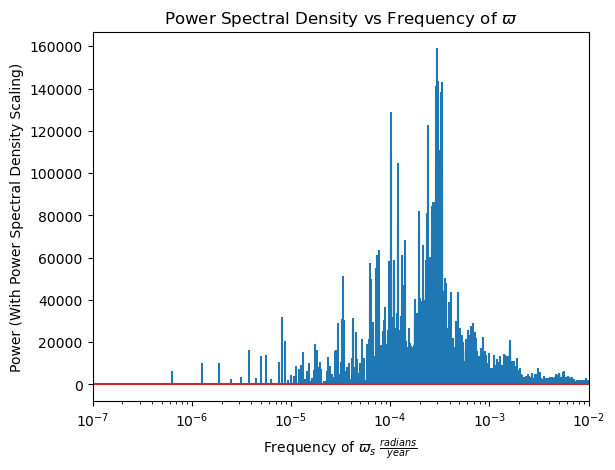

In [44]:
f,pxx = ft(times, long_peri_sat)

peak_idx = np.argmax(pxx)
peak_freq_precession = f[peak_idx]
print(f'Peak frequency: {f[peak_idx]*2*np.pi:.3e}')

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
#plt.axvline(f[peak_idx]*2*np.pi, color = 'red')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency of $\varpi_s$ $\frac{radians}{year}$")
plt.xlim(1e-7,1e-2)
plt.title(r'Power Spectral Density vs Frequency of $\varpi$')
plt.show()

Peak frequency: 2.922e-04


/tmp/ipykernel_960/1560107750.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(1e-7,0)


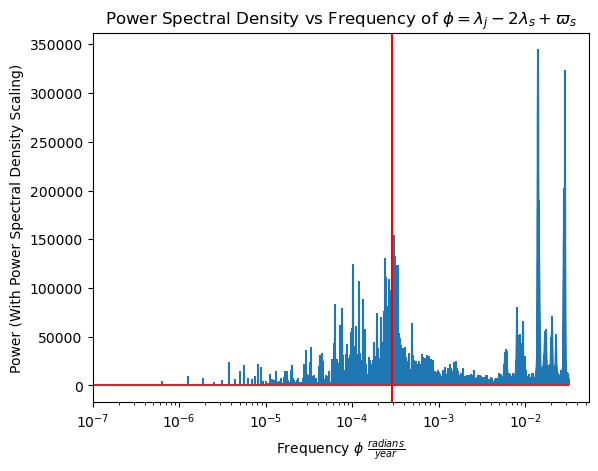

In [53]:
phi = l_j - 2*l_sat + long_peri_sat
f,pxx = ft(times, phi)

f, pxx = ft(times, phi)
f_filtered = f[f < 1e-3]
pxx_filtered = pxx[f < 1e-3]
peak_idx = np.argmax(pxx_filtered)
peak_freq_phi = f_filtered[peak_idx]
print(f'Peak frequency: {peak_freq_phi*2*np.pi:.3e}')

plt.stem(f*2*np.pi,pxx,markerfmt = "none",label = 'Frequencies found through simulation')
plt.axvline(peak_freq_phi*2*np.pi, color = 'red')
plt.xscale('log')
plt.ylabel('Power (With Power Spectral Density Scaling)')
plt.xlabel(r"Frequency $\phi$ $\frac{radians}{year}$")
plt.title(r'Power Spectral Density vs Frequency of $\phi = \lambda_j - 2\lambda_s + \varpi_s$')
plt.xlim(1e-7,0)
plt.show()

In [54]:
print(fr'Ratio of time Peak frquencies phi/varpi: {peak_freq_phi/peak_freq_precession: .3e}')

Ratio of time Peak frquencies phi/varpi:  9.894e-01
